In [15]:
import yaml
import os
from pathlib import Path
import jax.numpy as jnp
import matplotlib.pyplot as plt
from generative_uncertainty.compute_uncertainty import get_uncertainty_scores 
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
config = "config.yml"
config_data = {}
if os.path.exists(config):
    with open(config, 'r') as f:
        config_data = yaml.safe_load(f) or {} 
else:
    print(f"Warning: Config file '{config}' not found. Using defaults.")


In [17]:
trained_models_dir = config_data['deep-ensemble']['trained_models_dir']
real_dataset_path = trained_models_dir.format(seed=0) + "/real_dataset.npy"
real_data = jnp.load(real_dataset_path)
print(f"loaded real data : {real_data.shape}")

loaded real data : (100000, 2)


In [18]:
samples_cache_dir = config_data['sampling']['samples_cache_dir']
ensemble_samples_llla = jnp.load(Path(samples_cache_dir) / "llla_ensemble_samples.npy")
ensemble_samples_deep = jnp.load(Path(samples_cache_dir) / "deep_ensemble_samples.npy")
print(f"loaded ensemble samples: {ensemble_samples_llla.shape}")
base_samples_llla = ensemble_samples_llla[0]
base_samples_deep = ensemble_samples_deep[0]

uncertainty_scores_deep = get_uncertainty_scores(ensemble_samples_deep)
uncertainty_scores_llla = get_uncertainty_scores(ensemble_samples_llla)
uncertainty_scores_deep.shape

loaded ensemble samples: (6, 100000, 2)


(100000,)

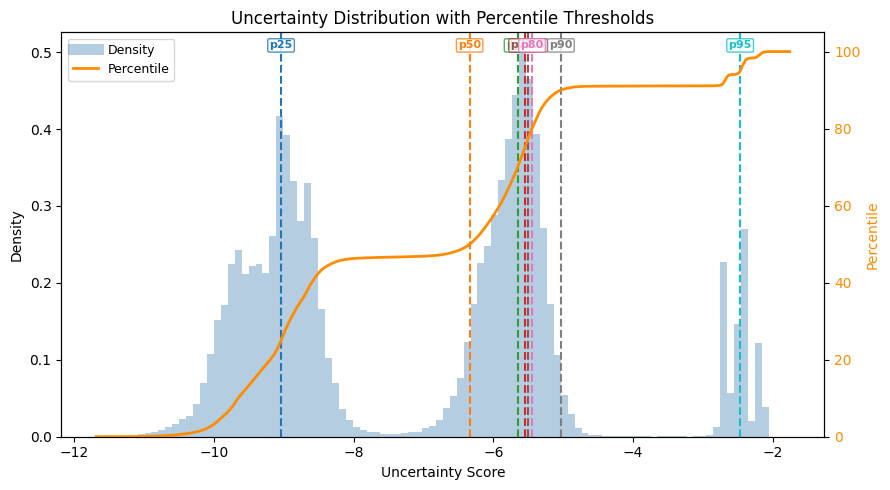

In [27]:
from generative_uncertainty.plots import plot_uncertainty_threshold_analysis
plot_uncertainty_threshold_analysis(uncertainty_scores_llla)

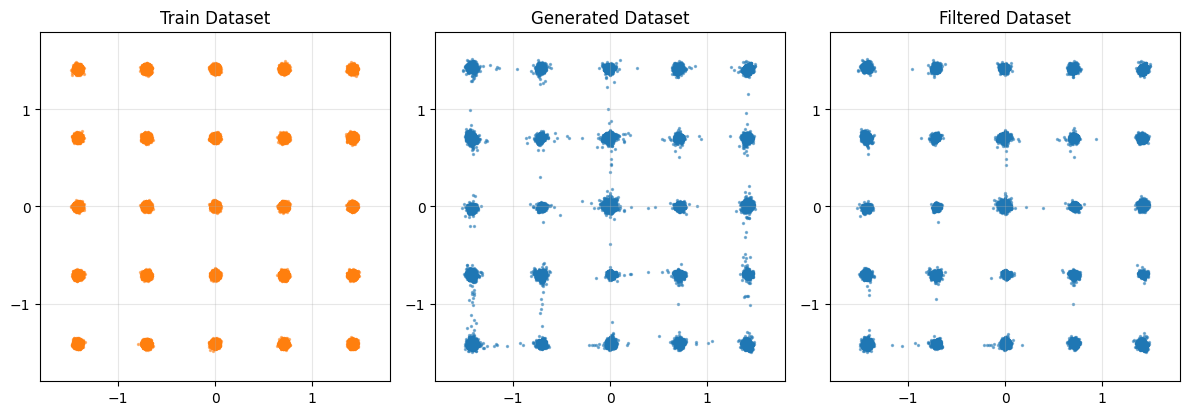

In [ ]:
percentile_score = jnp.percentile(uncertainty_scores_deep, 80)
confident_mask = uncertainty_scores_deep <= percentile_score
filtered_samples = base_samples_deep[confident_mask]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].scatter(real_data[:, 0], real_data[:, 1], s=2, alpha=0.5, color='tab:orange')
axes[0].set_title("Train Dataset")

axes[1].scatter(base_samples_deep[:, 0], base_samples_deep[:, 1], s=2, alpha=0.5, color='tab:blue')
axes[1].set_title("Generated Dataset")

axes[2].scatter(filtered_samples[:, 0], filtered_samples[:, 1], s=2, alpha=0.5, color='tab:blue')
axes[2].set_title("Filtered Dataset")

for ax in axes:
    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-1.8, 1.8)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.3)
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])
    
plt.tight_layout()
plt.show()

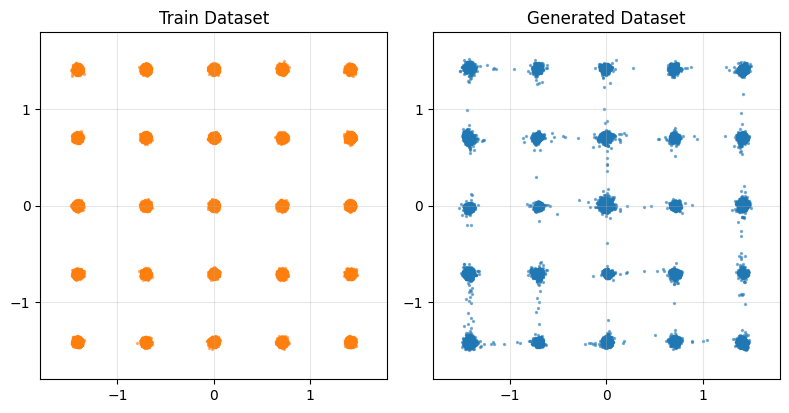

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].scatter(real_data[:, 0], real_data[:, 1], s=2, alpha=0.5, color='tab:orange')
axes[0].set_title("Train Dataset")

axes[1].scatter(base_samples_deep[:, 0], base_samples_deep[:, 1], s=2, alpha=0.5, color='tab:blue')
axes[1].set_title("Generated Dataset")

for ax in axes:
    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-1.8, 1.8)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.3)
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])
    
plt.tight_layout()
plt.show()

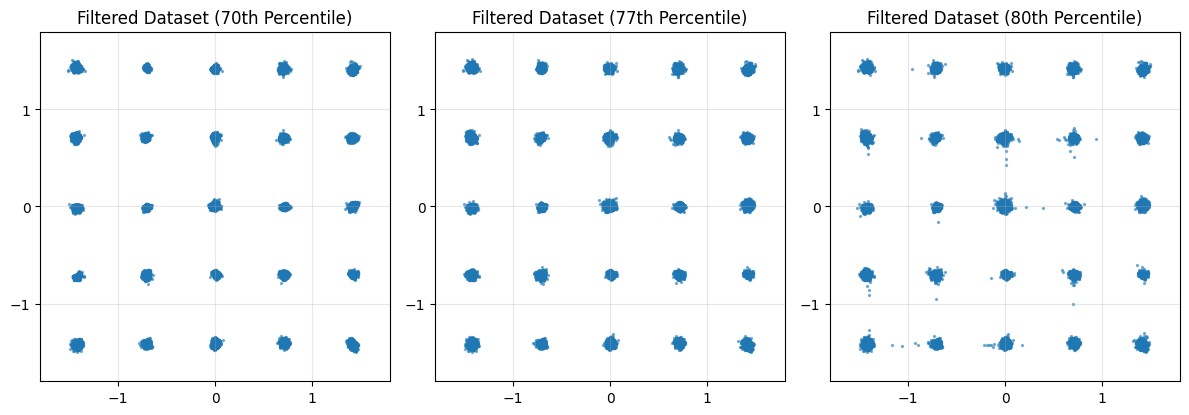

In [65]:

percentiles = [70, 77, 80]

fig, axes = plt.subplots(1, len(percentiles), figsize=(12, 4))

for i, percentile in enumerate(percentiles):
    percentile_score = jnp.percentile(uncertainty_scores_deep, percentile)
    confident_mask = uncertainty_scores_deep <= percentile_score
    filtered_samples = base_samples_deep[confident_mask]
    axes[i].scatter(filtered_samples[:, 0], filtered_samples[:, 1], s=2, alpha=0.5, color='tab:blue')
    axes[i].set_title(f"Filtered Dataset ({percentile}th Percentile)")

for ax in axes:
    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-1.8, 1.8)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.3)
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])
    
plt.tight_layout()
plt.show()

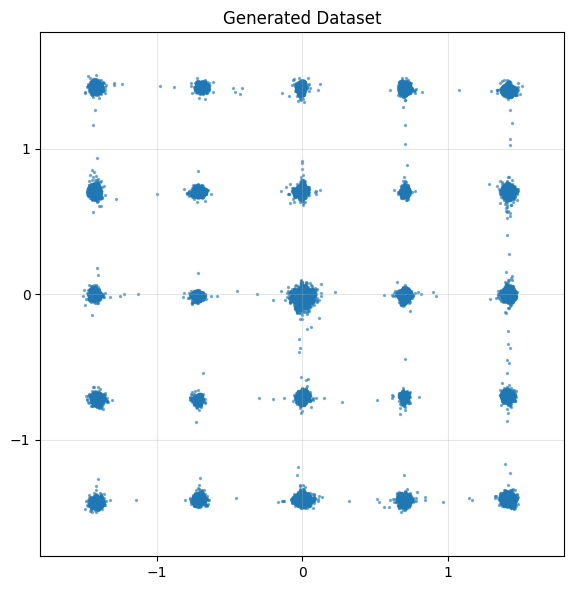

In [9]:
# plot of samples from one of the ensemble members
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(ensemble_samples[1, :, 0], ensemble_samples[1, :, 1], s=2, alpha=0.5, color='tab:blue')
ax.set_title("Generated Dataset")
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3)
ax.set_xticks([-1, 0, 1])
ax.set_yticks([-1, 0, 1])
plt.tight_layout()

In [28]:
from generative_uncertainty.scoring import extract_true_gmm_params, evaluate_exact_gmm, gmm_score_percentiles
true_means, true_var = extract_true_gmm_params()

/zhome/99/b/213811/thesis/DIFF-UQ/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [46]:
df_llla_gmm = gmm_score_percentiles(real_data, ensemble_samples_llla, uncertainty_scores_llla)
df_deep_gmm = gmm_score_percentiles(real_data, ensemble_samples_deep, uncertainty_scores_deep)

  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

Running 20 Monte Carlo iterations


Monte Carlo Iterations:   0%|          | 0/20 [00:00<?, ?it/s]

In [48]:
real_data_baseline = evaluate_exact_gmm(real_data, true_means, true_var)

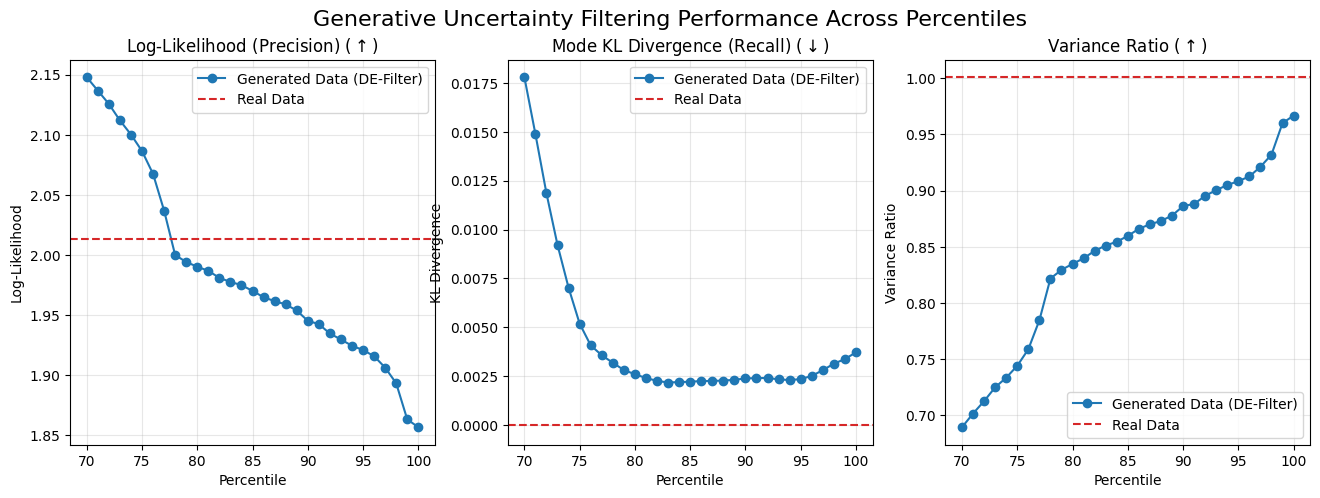

In [ ]:
import numpy as np
import pandas as pd
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Generative Uncertainty Filtering Performance Across Percentiles", fontsize=16)
axes[0].plot(df_deep_gmm.columns, df_deep_gmm.loc['avg_log_likelihood'], marker='o', label='Generated Data (DE-Filter)')
axes[1].plot(df_deep_gmm.columns, df_deep_gmm.loc['mode_kl_divergence'], marker='o', label='Generated Data (DE-Filter)')
axes[2].plot(df_deep_gmm.columns, df_deep_gmm.loc['variance_ratio'], marker='o', label='Generated Data (DE-Filter)')
# axes[2].fill_between(np.asarray(df_deep_mmd.columns), pd.to_numeric(df_deep_mmd.loc['ci_lower']), pd.to_numeric(df_deep_mmd.loc['ci_upper']), color='tab:blue', alpha=0.2, label='95% CI (DE-Filter)')

# axes[0].plot(df_llla_gmm.columns, df_llla_gmm.loc['avg_log_likelihood'], marker='x', label='Generated Data (LLLA-Filter)')
# axes[1].plot(df_llla_gmm.columns, df_llla_gmm.loc['mode_kl_divergence'], marker='x', label='Generated Data (LLLA-Filter)')
# axes[2].plot(df_llla_gmm.columns, df_llla_gmm.loc['variance_ratio'], marker='x', label='Generated Data (LLLA-Filter)')

# axes[2].fill_between(np.asarray(df_llla_mmd.columns), pd.to_numeric(df_llla_mmd.loc['ci_lower']), pd.to_numeric(df_llla_mmd.loc['ci_upper']), color='tab:orange', alpha=0.2, label='95% CI (LLLA-Filter)')
axes[0].axhline(real_data_baseline['avg_log_likelihood'], color='tab:red', linestyle='--', label='Real Data')
axes[1].axhline(real_data_baseline['mode_kl_divergence'], color='tab:red', linestyle='--', label='Real Data')
axes[2].axhline(real_data_baseline['variance_ratio'], color='tab:red', linestyle='--', label='Real Data')
# axes[2].axhline(ref_mmd['mean'], color='tab:orange', linestyle='--', label='Real Data')
# axes[2].fill_between([70, 100], ref_mmd['ci_lower'], ref_mmd['ci_upper'], color='tab:orange', alpha=0.2, label='95% CI (Real Data)')
axes[0].set_xlabel('Percentile')
axes[0].set_ylabel('Log-Likelihood')
axes[0].set_title(r'Log-Likelihood (Precision) ($\uparrow$)')
axes[1].set_xlabel('Percentile')
axes[1].set_ylabel('KL Divergence')
axes[1].set_title(r'Mode KL Divergence (Recall) ($\downarrow$)')
axes[2].set_xlabel('Percentile')
axes[2].set_ylabel('Variance Ratio')
axes[2].set_title(r'Variance Ratio ($\uparrow$)')
axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[2].grid(True, alpha=0.3)
# axes[1].set_xlim(80, 100)
axes[1].set_ylim(-0.001)
axes[0].legend()
axes[1].legend()
axes[2].legend()

In [19]:
from generative_uncertainty.scoring import mmd_score_percentiles
from generative_uncertainty.scoring import estimator, single_rbf_mmd

In [20]:
percentiles = [70, 72, 75, 76, 77, 78, 79, 80, 85, 90, 95, 100]
mmd_df_deep = mmd_score_percentiles(real_data, ensemble_samples_deep, uncertainty_scores_deep, gamma=0.2, percentiles=percentiles, num_iterations=30, subsample_size=10000)
ref_mmd = estimator(lambda X, Y: single_rbf_mmd(X, Y, gamma=0.2), real_data, real_data, num_iterations=30, subsample_size=10000)

  0%|          | 0/12 [00:00<?, ?it/s]

Running 30 Monte Carlo iterations


Monte Carlo Iterations:   0%|          | 0/30 [00:00<?, ?it/s]

Running 30 Monte Carlo iterations


Monte Carlo Iterations:   0%|          | 0/30 [00:00<?, ?it/s]

...

Monte Carlo Iterations:   0%|          | 0/30 [00:00<?, ?it/s]

Running 30 Monte Carlo iterations


Monte Carlo Iterations:   0%|          | 0/30 [00:00<?, ?it/s]

Running 30 Monte Carlo iterations


Monte Carlo Iterations:   0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
saved_df = pd.DataFrame(mmd_df_deep)
saved_df.to_csv("mmd_deep_percentiles.csv", index=False)

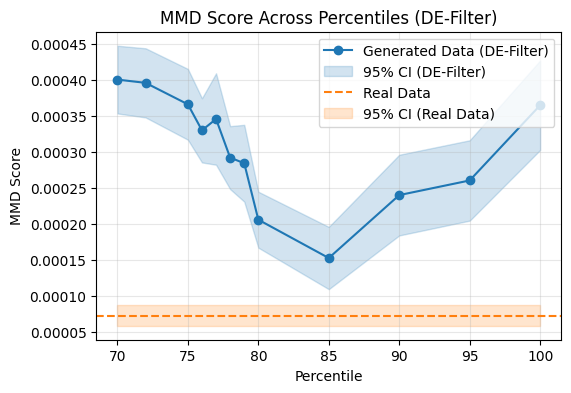

In [21]:
import pandas as pd
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mmd_df_deep.columns, mmd_df_deep.loc['mean'], marker='o', label='Generated Data (DE-Filter)')
ax.fill_between(mmd_df_deep.columns, pd.to_numeric(mmd_df_deep.loc['ci_lower']), pd.to_numeric(mmd_df_deep.loc['ci_upper']), color='tab:blue', alpha=0.2, label='95% CI (DE-Filter)')
ax.axhline(ref_mmd['mean'], color='tab:orange', linestyle='--', label='Real Data')
ax.fill_between(mmd_df_deep.columns, ref_mmd['ci_lower'], ref_mmd['ci_upper'], color='tab:orange', alpha=0.2, label='95% CI (Real Data)')   
ax.set_xlabel('Percentile')
ax.set_ylabel('MMD Score')
ax.set_title('MMD Score Across Percentiles (DE-Filter)')
ax.grid(True, alpha=0.3)
ax.legend()